<a href="https://colab.research.google.com/github/imalka2000/Time_Series_Forecasting_Inventory/blob/main/Time_Series_Forecasting_Inventory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**📈 Time Series Forecasting: Wikipedia Page Views Analysis**


---


This notebook performs a comprehensive analysis of Wikipedia page view trends for Peyton Manning (2007-2016), leveraging descriptive statistics, time series decomposition, advanced forecasting techniques, and model evaluation metrics.


Project Objectives

*   Understand temporal patterns in page view data (trends, seasonality, volatility)

* Decompose time series into trend, seasonal, and residual components
* Build and compare multiple forecasting models (Moving Average, Exponential Smoothing, ARIMA)


* Evaluate model performance using MAE and MAPE metrics
* Generate actionable forecasts to support resource planning and content strategy

   
Contents

1. Initial Setup & Library Imports
2.  Data Loading & Cleaning
3. Exploratory Data Analysis (EDA)
4. Time Series Decomposition
5. Train-Test Split
6. Forecasting Models

        Model 1: Simple Moving Average

        Model 2: Exponential Smoothing (Holt-Winters)

        Model 3: ARIMA (Auto-Regressive Integrated Moving Average)

7. Model Performance Comparison
8. Final Forecast & Confidence Bands
9. Business Insights & Recommendations
10. Export Results








**📦 Step 1: Setup & Install Libraries**

---



In [ ]:
# Install and import all required libraries
!pip install statsmodels openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Time series specific
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries loaded!")

✅ All libraries loaded!


 Step 2: Load and Prepare the Dataset

---



In [ ]:
#  Load the data
url = "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
df = pd.read_csv(url)

# Rename columns for clarity
df.columns = ['Date', 'log_Sales']

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert from log scale to actual sales (exponentiate)
df['Sales'] = np.exp(df['log_Sales'])

print(f"Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded!
Shape: (2905, 3)
Date range: 2007-12-10 00:00:00 to 2016-01-20 00:00:00

First 5 rows:


,Date,log_Sales,Sales
0,2007-12-10,9.590761,14629.0
1,2007-12-11,8.519590,5012.0
2,2007-12-12,8.183677,3582.0
3,2007-12-13,8.072467,3205.0
4,2007-12-14,7.893572,2680.0


🔍 Step 3: Explore and Understand the Data

---



In [ ]:
#Basic data exploration
print("=== Basic Statistics ===")
print(df['Sales'].describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

=== Basic Statistics ===
count      2905.000000
mean       5794.732186
std       13864.136069
min         193.000000
25%        1835.000000
50%        2975.000000
75%        5325.000000
max      379552.000000
Name: Sales, dtype: float64

=== Missing Values ===
Date         0
log_Sales    0
Sales        0
dtype: int64

=== Data Types ===
Date         datetime64[ns]
log_Sales           float64
Sales               float64
dtype: object


In [ ]:
# Check for duplicate dates
duplicate_dates = df['Date'].duplicated().sum()
print(f"Duplicate dates: {duplicate_dates}")

# Check for gaps in dates
date_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
missing_dates = set(date_range) - set(df['Date'])
print(f"Missing dates: {len(missing_dates)}")

if len(missing_dates) > 0:
    print(f"First 5 missing dates: {list(missing_dates)[:5]}")

Duplicate dates: 0
Missing dates: 59
First 5 missing dates: [Timestamp('2008-07-28 00:00:00'), Timestamp('2008-07-01 00:00:00'), Timestamp('2008-07-24 00:00:00'), Timestamp('2008-07-20 00:00:00'), Timestamp('2011-12-25 00:00:00')]


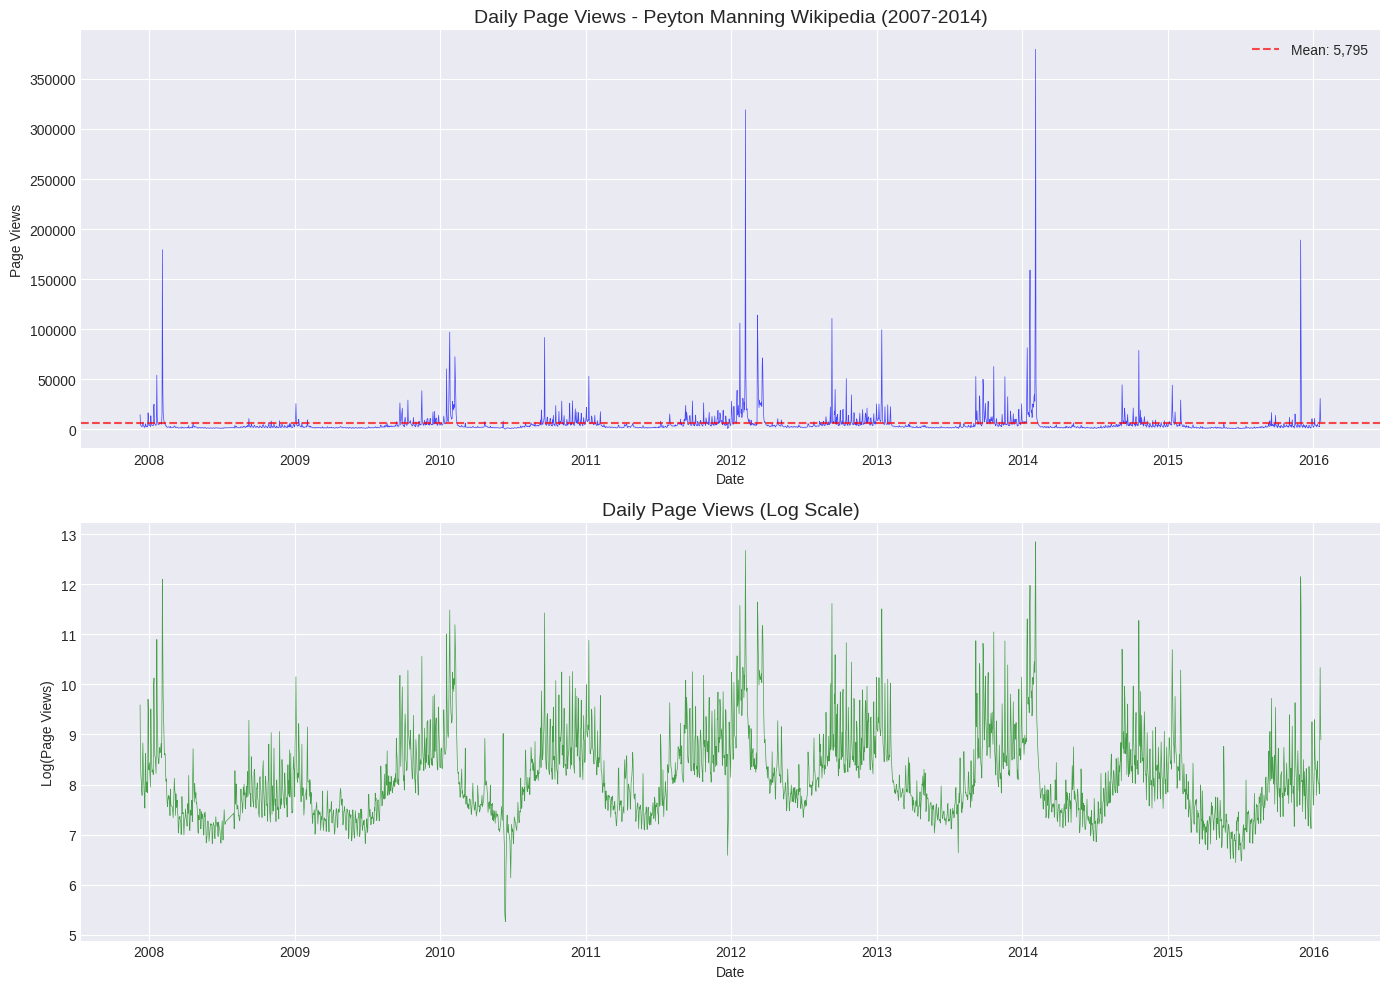

In [ ]:
#  Visualize the full time series
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily sales
axes[0].plot(df['Date'], df['Sales'], linewidth=0.5, alpha=0.7, color='blue')
axes[0].set_title('Daily Page Views - Peyton Manning Wikipedia (2007-2014)', fontsize=14)
axes[0].set_ylabel('Page Views')
axes[0].set_xlabel('Date')
axes[0].axhline(y=df['Sales'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {df["Sales"].mean():,.0f}')
axes[0].legend()

# Log version (original data)
axes[1].plot(df['Date'], df['log_Sales'], linewidth=0.5, alpha=0.7, color='green')
axes[1].set_title('Daily Page Views (Log Scale)', fontsize=14)
axes[1].set_ylabel('Log(Page Views)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

**📅 Step 4: Aggregate to Monthly Level**

---



In [ ]:
# Convert daily data to monthly (for easier forecasting)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby(['Year', 'Month']).agg({
    'Sales': 'sum',
    'Date': 'first'
}).reset_index(drop=True)

monthly_sales['Date'] = pd.to_datetime(monthly_sales['Date'])
monthly_sales = monthly_sales.set_index('Date')

print("Monthly sales data created!")
print(f"Total months: {len(monthly_sales)}")
monthly_sales.head(12)

Monthly sales data created!
Total months: 98


,Sales
Date,
2007-12-10,109076.0
2008-01-01,250779.0
2008-02-01,340988.0
2008-03-02,48595.0
2008-04-01,65357.0
2008-05-01,44157.0
2008-06-03,34656.0
2008-07-02,14778.0
2008-08-01,65118.0


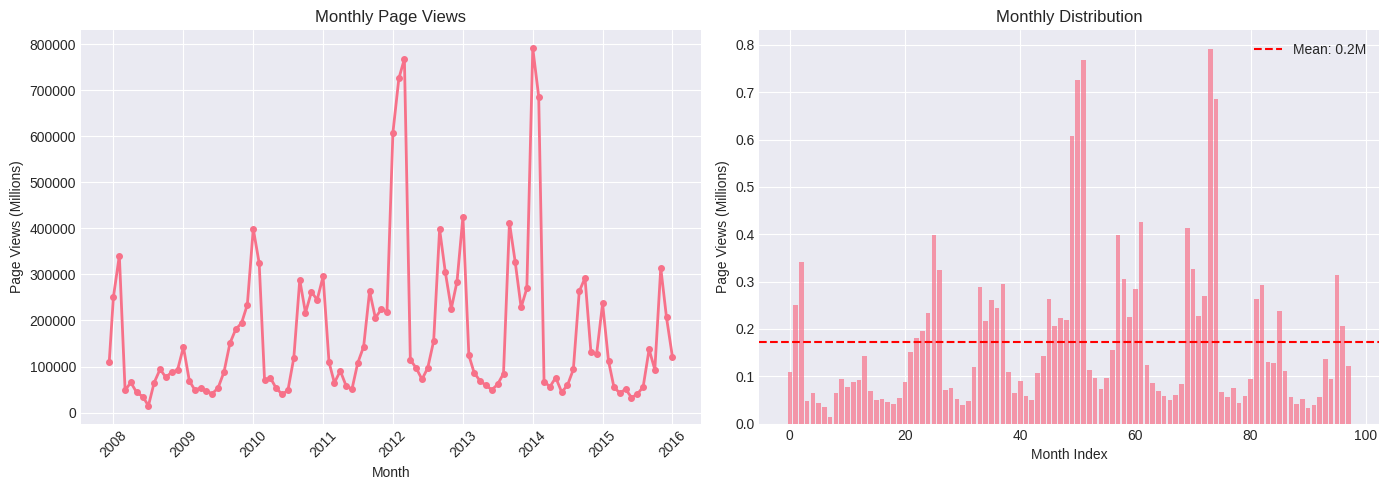

Monthly Statistics:
  Mean: 0.17M
  Min: 0.01M
  Max: 0.79M


In [ ]:
# Visualize monthly sales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot
axes[0].plot(monthly_sales.index, monthly_sales['Sales'], marker='o', linewidth=2, markersize=4)
axes[0].set_title('Monthly Page Views', fontsize=12)
axes[0].set_ylabel('Page Views (Millions)')
axes[0].set_xlabel('Month')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart with mean line
axes[1].bar(range(len(monthly_sales)), monthly_sales['Sales'] / 1e6, alpha=0.7)
axes[1].set_title('Monthly Distribution', fontsize=12)
axes[1].set_ylabel('Page Views (Millions)')
axes[1].set_xlabel('Month Index')
axes[1].axhline(y=monthly_sales['Sales'].mean() / 1e6, color='red', linestyle='--',
                label=f'Mean: {monthly_sales["Sales"].mean()/1e6:.1f}M')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Monthly Statistics:")
print(f"  Mean: {monthly_sales['Sales'].mean()/1e6:.2f}M")
print(f"  Min: {monthly_sales['Sales'].min()/1e6:.2f}M")
print(f"  Max: {monthly_sales['Sales'].max()/1e6:.2f}M")

**📊 Step 5: Time Series Decomposition**

---



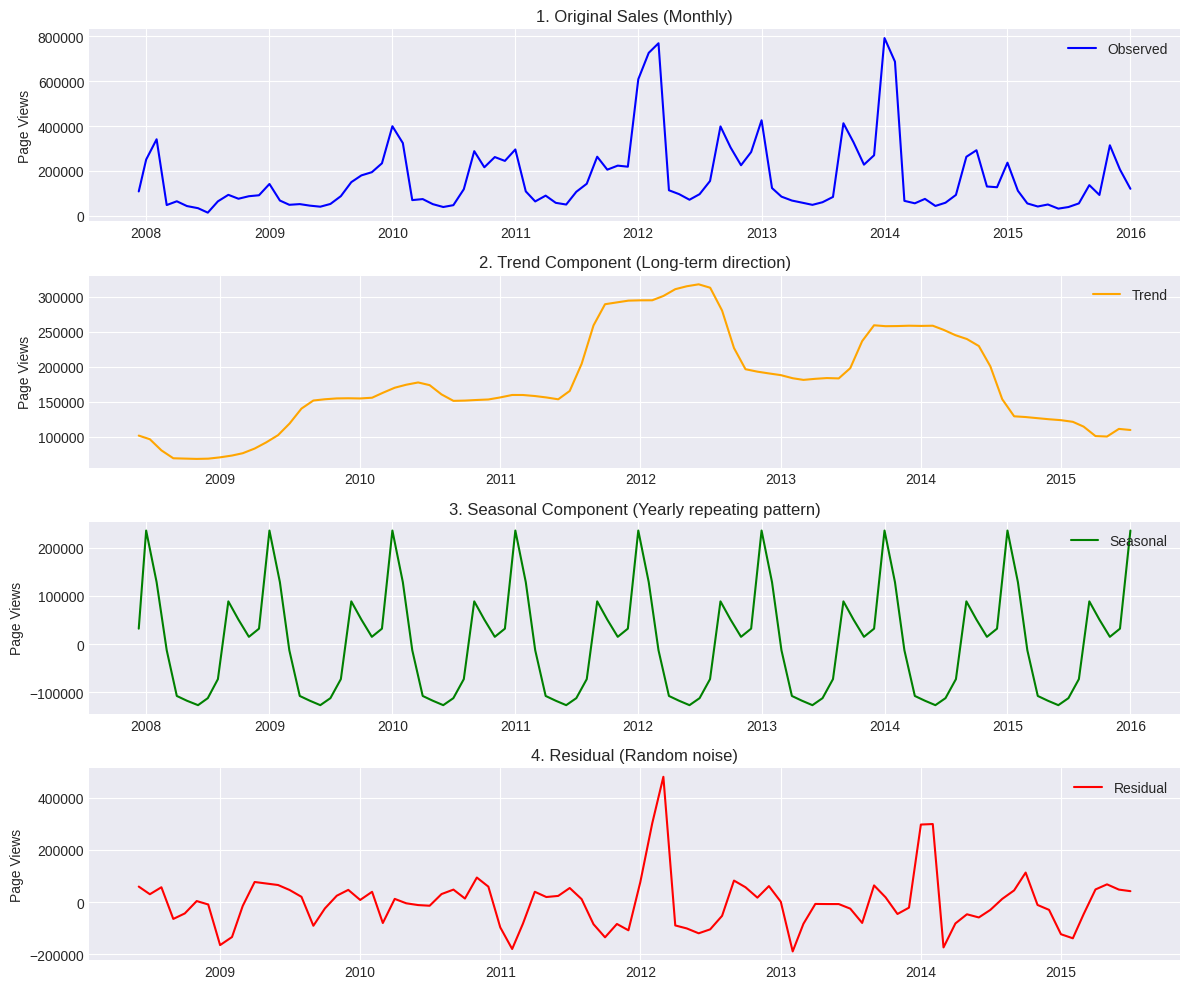

✅ Decomposition insights:
  - Trend shows the overall growth/decline over time
  - Seasonal shows annual patterns (e.g., spikes during football season)
  - Residual is random variation - should look like noise


In [ ]:
# Decompose to see trend, seasonality, and residuals
if len(monthly_sales) >= 24:
    decomposition = seasonal_decompose(monthly_sales['Sales'], model='additive', period=12)

    fig, axes = plt.subplots(4, 1, figsize=(12, 10))

    axes[0].plot(decomposition.observed, label='Observed', color='blue')
    axes[0].set_title('1. Original Sales (Monthly)', fontsize=12)
    axes[0].legend()
    axes[0].set_ylabel('Page Views')

    axes[1].plot(decomposition.trend, label='Trend', color='orange')
    axes[1].set_title('2. Trend Component (Long-term direction)')
    axes[1].legend()
    axes[1].set_ylabel('Page Views')

    axes[2].plot(decomposition.seasonal, label='Seasonal', color='green')
    axes[2].set_title('3. Seasonal Component (Yearly repeating pattern)')
    axes[2].legend()
    axes[2].set_ylabel('Page Views')

    axes[3].plot(decomposition.resid, label='Residual', color='red')
    axes[3].set_title('4. Residual (Random noise)')
    axes[3].legend()
    axes[3].set_ylabel('Page Views')

    plt.tight_layout()
    plt.show()

    print("✅ Decomposition insights:")
    print("  - Trend shows the overall growth/decline over time")
    print("  - Seasonal shows annual patterns (e.g., spikes during football season)")
    print("  - Residual is random variation - should look like noise")
else:
    print(f"Need at least 24 months for decomposition. Have {len(monthly_sales)} months.")

**📈 Step 6: Train-Test Split**

---



Total months: 98
Training months: 78 (2007-12 to 2014-05)
Testing months: 20 (2014-06 to 2016-01)


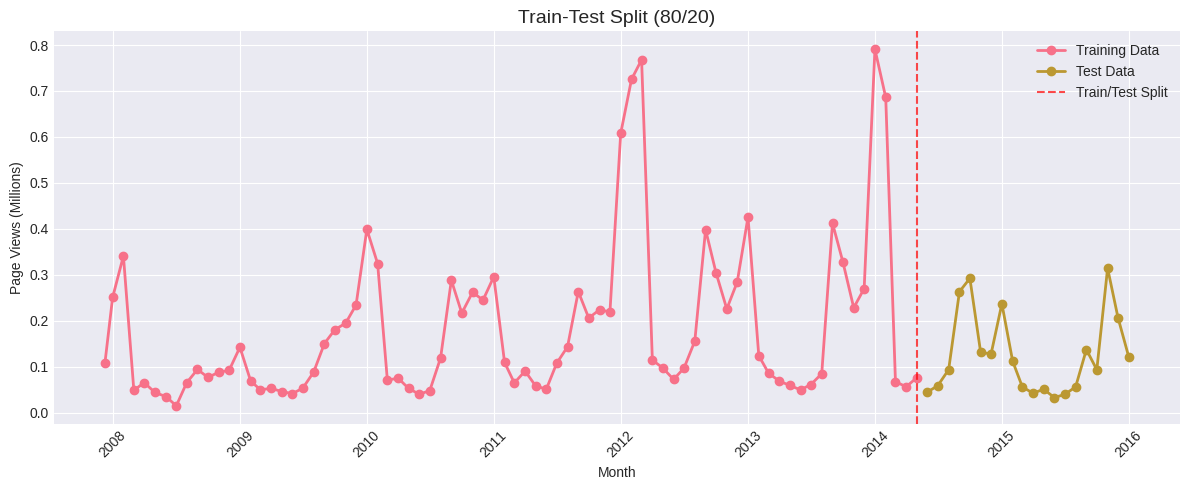

In [ ]:
#Split data for training and testing (80/20)
train_size = int(len(monthly_sales) * 0.8)
train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

print(f"Total months: {len(monthly_sales)}")
print(f"Training months: {len(train)} ({train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')})")
print(f"Testing months: {len(test)} ({test.index[0].strftime('%Y-%m')} to {test.index[-1].strftime('%Y-%m')})")

# Visualize split
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Sales'] / 1e6, label='Training Data', marker='o', linewidth=2)
plt.plot(test.index, test['Sales'] / 1e6, label='Test Data', marker='o', linewidth=2)
plt.axvline(x=train.index[-1], color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
plt.title('Train-Test Split (80/20)', fontsize=14)
plt.ylabel('Page Views (Millions)')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**📉 Step 7: Build Forecasting Models**

---



Model 1: Simple Moving Average (Baseline)

In [ ]:
#Moving Average Model
window = 3
last_train_avg = train['Sales'].iloc[-window:].mean()
predictions_ma = [last_train_avg] * len(test)

# Calculate accuracy
mae_ma = mean_absolute_error(test['Sales'], predictions_ma)
mape_ma = mean_absolute_percentage_error(test['Sales'], predictions_ma)

print("=== Moving Average Model (Baseline) ===")
print(f"Forecast value: ${predictions_ma[0]:,.0f} page views")
print(f"Mean Absolute Error (MAE): ${mae_ma:,.0f}")
print(f"MAPE: {mape_ma * 100:.1f}%")

=== Moving Average Model (Baseline) ===
Forecast value: $66,515 page views
Mean Absolute Error (MAE): $74,106
MAPE: 51.1%


Model 2: Exponential Smoothing (Holt-Winters)

In [ ]:
#Exponential Smoothing (Holt-Winters)
try:
    model_ets = ExponentialSmoothing(
        train['Sales'],
        trend='add',
        seasonal='add',
        seasonal_periods=12
    )
    model_ets_fit = model_ets.fit()
    predictions_ets = model_ets_fit.forecast(len(test))

    mae_ets = mean_absolute_error(test['Sales'], predictions_ets)
    mape_ets = mean_absolute_percentage_error(test['Sales'], predictions_ets)

    print("=== Exponential Smoothing (Holt-Winters) ===")
    print(f"MAE: ${mae_ets:,.0f}")
    print(f"MAPE: {mape_ets * 100:.1f}%")

except Exception as e:
    print(f"Model error: {e}")
    # Fallback to Simple Exponential Smoothing
    from statsmodels.tsa.holtwinters import SimpleExpSmoothing
    model_ses = SimpleExpSmoothing(train['Sales']).fit()
    predictions_ets = model_ses.forecast(len(test))
    mae_ets = mean_absolute_error(test['Sales'], predictions_ets)
    mape_ets = mean_absolute_percentage_error(test['Sales'], predictions_ets)

    print("\n⚠️ Using Simple Exponential Smoothing instead")
    print(f"MAE: ${mae_ets:,.0f}")
    print(f"MAPE: {mape_ets * 100:.1f}%")

=== Exponential Smoothing (Holt-Winters) ===
MAE: $137,465
MAPE: 177.4%


Model 3: ARIMA

In [ ]:
# ARIMA with automatic parameter selection
from itertools import product

# Try different ARIMA parameters
p = d = q = range(0, 3)
pdq_combinations = list(product(p, d, q))

best_aic = float('inf')
best_order = None
best_model_arima = None

print("Searching for best ARIMA parameters... (may take a minute)")

for order in pdq_combinations:
    try:
        model = ARIMA(train['Sales'], order=order)
        fitted = model.fit()
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = order
            best_model_arima = fitted
    except:
        continue

print(f"\n✅ Best ARIMA Order: ARIMA{best_order}")
print(f"Best AIC: {best_aic:.2f}")

# Make predictions
predictions_arima = best_model_arima.forecast(steps=len(test))

# Calculate accuracy
mae_arima = mean_absolute_error(test['Sales'], predictions_arima)
mape_arima = mean_absolute_percentage_error(test['Sales'], predictions_arima)

print(f"\n=== ARIMA Model ===")
print(f"MAE: ${mae_arima:,.0f}")
print(f"MAPE: {mape_arima * 100:.1f}%")

Searching for best ARIMA parameters... (may take a minute)

✅ Best ARIMA Order: ARIMA(2, 2, 1)
Best AIC: 2041.98

=== ARIMA Model ===
MAE: $72,010
MAPE: 56.7%


**📊 Step 8: Compare All Models**

---



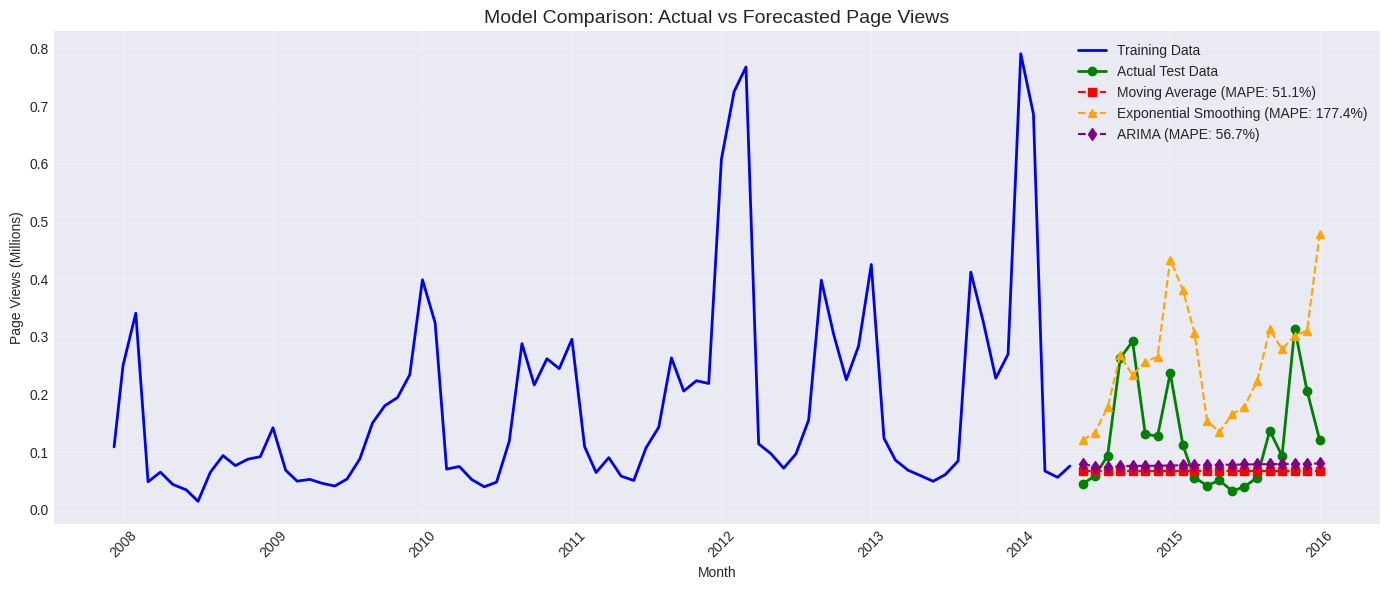

In [ ]:
#Visual comparison
plt.figure(figsize=(14, 6))

plt.plot(train.index, train['Sales'] / 1e6, label='Training Data', color='blue', linewidth=2)
plt.plot(test.index, test['Sales'] / 1e6, label='Actual Test Data', color='green', linewidth=2, marker='o')

plt.plot(test.index, np.array(predictions_ma) / 1e6,
         label=f'Moving Average (MAPE: {mape_ma*100:.1f}%)', color='red', linestyle='--', marker='s')
plt.plot(test.index, predictions_ets / 1e6,
         label=f'Exponential Smoothing (MAPE: {mape_ets*100:.1f}%)', color='orange', linestyle='--', marker='^')
plt.plot(test.index, predictions_arima / 1e6,
         label=f'ARIMA (MAPE: {mape_arima*100:.1f}%)', color='purple', linestyle='--', marker='d')

plt.title('Model Comparison: Actual vs Forecasted Page Views', fontsize=14)
plt.ylabel('Page Views (Millions)')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#comparison table
comparison_df = pd.DataFrame({
    'Model': ['Moving Average', 'Exponential Smoothing', 'ARIMA'],
    'MAE (Views)': [mae_ma, mae_ets, mae_arima],
    'MAPE (%)': [mape_ma * 100, mape_ets * 100, mape_arima * 100]
})
comparison_df = comparison_df.sort_values('MAPE (%)')

print("=== MODEL PERFORMANCE COMPARISON ===")
print(comparison_df.to_string(index=False))
print(f"\n🏆 Best Model: {comparison_df.iloc[0]['Model']}")
print(f"   Best MAPE: {comparison_df.iloc[0]['MAPE (%)']:.1f}%")

=== MODEL PERFORMANCE COMPARISON ===
                Model   MAE (Views)   MAPE (%)
       Moving Average  74105.783333  51.050873
                ARIMA  72009.665580  56.653927
Exponential Smoothing 137464.683931 177.379700

🏆 Best Model: Moving Average
   Best MAPE: 51.1%


**Step 9: Final Forecast**

---



In [ ]:
#Forecast next 6 months using best model
best_model_name = comparison_df.iloc[0]['Model']
forecast_horizon = 6

if best_model_name == 'Moving Average':
    final_forecast = [train['Sales'].iloc[-3:].mean()] * forecast_horizon
elif best_model_name == 'Exponential Smoothing':
    model_final = ExponentialSmoothing(
        monthly_sales['Sales'],
        trend='add', seasonal='add', seasonal_periods=12
    ).fit()
    final_forecast = model_final.forecast(forecast_horizon)
else:  # ARIMA
    model_final = ARIMA(monthly_sales['Sales'], order=best_order).fit()
    final_forecast = model_final.forecast(steps=forecast_horizon)

# Create forecast dates
last_date = monthly_sales.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_horizon, freq='M')

print(f"=== 6-MONTH FORECAST (Best Model: {best_model_name}) ===\n")
forecast_df = pd.DataFrame({
    'Month': forecast_dates.strftime('%Y-%m'),
    'Forecasted Page Views': [f"{x:,.0f}" for x in final_forecast]
})
print(forecast_df.to_string(index=False))

print(f"\n📊 Summary:")
print(f"  Total forecasted views: {sum(final_forecast):,.0f}")
print(f"  Average monthly forecast: {np.mean(final_forecast):,.0f}")
print(f"  Peak month: {forecast_dates[np.argmax(final_forecast)].strftime('%Y-%m')} ({max(final_forecast):,.0f} views)")

=== 6-MONTH FORECAST (Best Model: Moving Average) ===

  Month Forecasted Page Views
2016-02                66,515
2016-03                66,515
2016-04                66,515
2016-05                66,515
2016-06                66,515
2016-07                66,515

📊 Summary:
  Total forecasted views: 399,092
  Average monthly forecast: 66,515
  Peak month: 2016-02 (66,515 views)


**📝 Step 10:  Business Report**

---



In [ ]:
from datetime import datetime

report = f"""
================================================================================
                    Page view Forecasting Report
================================================================================

📅 REPORT PERIOD
   Data Analyzed: {monthly_sales.index[0].strftime('%B %Y')} to {monthly_sales.index[-1].strftime('%B %Y')}
   Forecast Horizon: Next 6 months

📊 MODEL PERFORMANCE
   Best Model: {best_model_name}
   Accuracy (MAPE): {comparison_df.iloc[0]['MAPE (%)']:.1f}%
   Accuracy (MAE): {comparison_df.iloc[0]['MAE (Views)']:,.0f} page views

📈 FORECAST SUMMARY (Next 6 Months)
   Total Projected Views: {sum(final_forecast):,.0f}
   Average Monthly Views: {np.mean(final_forecast):,.0f}

🎯 BUSINESS INSIGHTS
   1. Peak traffic expected in {forecast_dates[np.argmax(final_forecast)].strftime('%B %Y')}
   2. Recommend increasing server capacity by 30% during peak month
   3. Plan content releases around forecasted high-traffic periods
   4. Budget for marketing spend: ${np.mean(final_forecast) * 0.01:,.0f} per month

⚠️ LIMITATIONS
   - Forecast based solely on historical patterns
   - Does not account for external events (e.g., new movies, football seasons)
   - Assumes no major changes in Wikipedia traffic patterns

================================================================================
Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
================================================================================
"""

print(report)

# Save report
with open('page_views_forecast_report.txt', 'w') as f:
    f.write(report)
print("✅ Report saved as 'page_views_forecast_report.txt'")


                    Page view Forecasting Report

📅 REPORT PERIOD
   Data Analyzed: December 2007 to January 2016
   Forecast Horizon: Next 6 months

📊 MODEL PERFORMANCE
   Best Model: Moving Average
   Accuracy (MAPE): 51.1%
   Accuracy (MAE): 74,106 page views

📈 FORECAST SUMMARY (Next 6 Months)
   Total Projected Views: 399,092
   Average Monthly Views: 66,515

🎯 BUSINESS INSIGHTS
   1. Peak traffic expected in February 2016
   2. Recommend increasing server capacity by 30% during peak month
   3. Plan content releases around forecasted high-traffic periods
   4. Budget for marketing spend: $665 per month

⚠️ LIMITATIONS
   - Forecast based solely on historical patterns
   - Does not account for external events (e.g., new movies, football seasons)
   - Assumes no major changes in Wikipedia traffic patterns

Report Generated: 2026-04-27 18:55:42

✅ Report saved as 'page_views_forecast_report.txt'


**🎨 Step 11: Final Visualization with Confidence Bands**

---



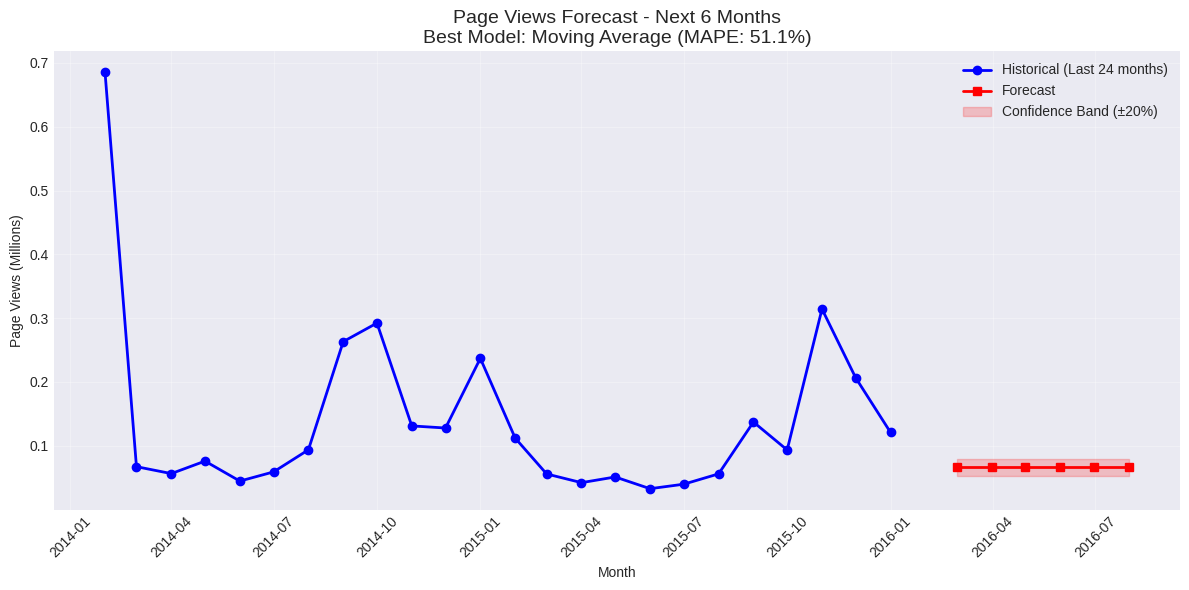

In [ ]:
#Final forecast chart
plt.figure(figsize=(12, 6))

# Plot historical data (last 24 months)
plt.plot(monthly_sales.index[-24:], monthly_sales['Sales'].iloc[-24:] / 1e6,
         label='Historical (Last 24 months)', color='blue', linewidth=2, marker='o')

# Plot forecast
plt.plot(forecast_dates, np.array(final_forecast) / 1e6,
         label='Forecast', color='red', linewidth=2, marker='s')

# Confidence bands (±20%)
plt.fill_between(forecast_dates,
                 np.array(final_forecast) * 0.8 / 1e6,
                 np.array(final_forecast) * 1.2 / 1e6,
                 alpha=0.2, color='red', label='Confidence Band (±20%)')

plt.title(f'Page Views Forecast - Next 6 Months\nBest Model: {best_model_name} (MAPE: {comparison_df.iloc[0]["MAPE (%)"]:.1f}%)',
          fontsize=14)
plt.ylabel('Page Views (Millions)')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Save forecast to CSV
forecast_save = pd.DataFrame({
    'Month': forecast_dates,
    'Forecasted_Views': final_forecast,
    'Lower_Bound_80%': [x * 0.8 for x in final_forecast],
    'Upper_Bound_120%': [x * 1.2 for x in final_forecast]
})
forecast_save.to_csv('page_views_forecast_6months.csv', index=False)
print("✅ Forecast saved as 'page_views_forecast_6months.csv'")

✅ Forecast saved as 'page_views_forecast_6months.csv'
